In [4]:
!pip install tensorflow-datasets

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

In [6]:
(x_mnist_train, y_mnist_train), (x_mnist_test, y_mnist_test) = keras.datasets.mnist.load_data()

In [7]:
ds_train, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True
)

In [8]:
x_emnist_train = np.array([x.numpy() for x, y in ds_train])
y_emnist_train = np.array([y.numpy() for x, y in ds_train])

x_emnist_test = np.array([x.numpy() for x, y in ds_test])
y_emnist_test = np.array([y.numpy() for x, y in ds_test])

In [9]:
x_emnist_train = np.array([x.numpy() for x, y in ds_train])
y_emnist_train = np.array([y.numpy() for x, y in ds_train])

x_emnist_test = np.array([x.numpy() for x, y in ds_test])
y_emnist_test = np.array([y.numpy() for x, y in ds_test])

In [14]:


x_mnist_train = x_mnist_train.reshape(-1,28,28,1)
x_mnist_test = x_mnist_test.reshape(-1,28,28,1)

x_emnist_train = x_emnist_train.reshape(-1,28,28,1)
x_emnist_test = x_emnist_test.reshape(-1,28,28,1)

In [15]:
x_train = np.concatenate((x_mnist_train, x_emnist_train))
y_train = np.concatenate((y_mnist_train, y_emnist_train))

x_test = np.concatenate((x_mnist_test, x_emnist_test))
y_test = np.concatenate((y_mnist_test, y_emnist_test))

In [16]:
# normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# classes
num_classes = 36

# one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [17]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(36, activation='softmax')
])

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 104s 49ms/step - accuracy: 0.7775 - loss: 0.7543 - val_accuracy: 0.8811 - val_loss: 0.3777
Epoch 2/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 101s 48ms/step - accuracy: 0.8853 - loss: 0.3706 - val_accuracy: 0.9078 - val_loss: 0.2813
Epoch 3/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 140s 48ms/step - accuracy: 0.9103 - loss: 0.2882 - val_accuracy: 0.9145 - val_loss: 0.2567
Epoch 4/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 142s 48ms/step - accuracy: 0.9215 - loss: 0.2496 - val_accuracy: 0.9216 - val_loss: 0.2458
Epoch 5/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 98s 47ms/step - accuracy: 0.9288 - loss: 0.2192 - val_accuracy: 0.9269 - val_loss: 0.2279


In [21]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9457 - loss: 0.1612
Accuracy: 0.9456855058670044


775/775 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
Digit: 0


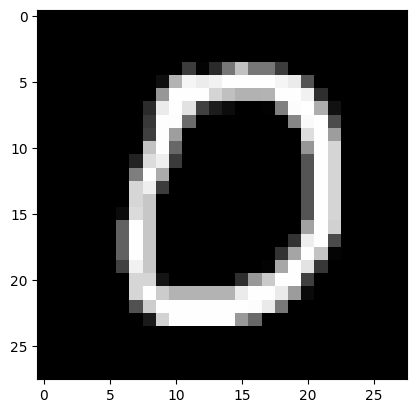

In [22]:
pred = model.predict(x_test)

index = 10
plt.imshow(x_test[index].reshape(28,28), cmap='gray')

label = np.argmax(pred[index])

if label <= 9:
    print("Digit:", label)
else:
    print("Letter:", chr(label - 9 + 64))

plt.show()

In [24]:
model.save("model.keras")